In [43]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

In [44]:
model = load_model(
    r"D:\project\MindSense\Early_Detection\models\mental_health_lstm.keras"
)

In [45]:
import numpy as np
from tensorflow.keras.models import load_model

In [46]:
X_test = np.load(r"D:\project\MindSense\Early_Detection\data\processed\X_test.npy")

y_test = np.load(r"D:\project\MindSense\Early_Detection\data\processed\y_test.npy")

In [47]:
model = load_model(
    r"D:\project\MindSense\Early_Detection\models\mental_health_lstm.keras"
)

In [48]:
y_pred = model.predict(X_test)

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [49]:
import numpy as np

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_true, y_pred_classes))

print(classification_report(y_true, y_pred_classes))

print(confusion_matrix(y_true, y_pred_classes))

Accuracy: 0.508745963401507
              precision    recall  f1-score   support

           0       0.50      0.89      0.64      3463
           1       0.00      0.00      0.00      1202
           2       0.00      0.00      0.00        35
           3       0.54      0.92      0.68       765
           5       0.00      0.00      0.00      1967

    accuracy                           0.51      7432
   macro avg       0.21      0.36      0.26      7432
weighted avg       0.29      0.51      0.37      7432

[[3077    0    0  386    0]
 [1077    0    0  125    0]
 [   0    0    0   35    0]
 [  61    0    0  704    0]
 [1922    0    0   45    0]]


d:\project\MindSense\Early_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\project\MindSense\Early_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\project\MindSense\Early_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [51]:
import numpy as np
from tensorflow.keras.models import load_model
import joblib

In [52]:
X_test = np.load(
    r"D:\project\MindSense\Early_Detection\data\processed\X_test.npy"
)

y_test = np.load(
    r"D:\project\MindSense\Early_Detection\data\processed\y_test.npy"
)

print(X_test.shape)
print(y_test.shape)

(7432, 60, 11)
(7432, 6)


In [53]:
model = load_model(
    r"D:\project\MindSense\Early_Detection\models\mental_health_lstm.keras"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,204 (254.71 KB)

 Trainable params: 21,734 (84.90 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 43,470 (169.81 KB)

In [54]:
y_pred = model.predict(X_test)

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [55]:
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

In [56]:
mental_encoder = joblib.load(
    r"D:\project\MindSense\Early_Detection\artifacts\mental_encoder.pkl"
)

In [57]:
predicted_labels = mental_encoder.inverse_transform(y_pred_classes)

actual_labels = mental_encoder.inverse_transform(y_true)

In [58]:
print(predicted_labels[:10])
print(actual_labels[:10])

['Anxiety' 'Anxiety' 'Anxiety' 'Anxiety' 'Anxiety' 'Anxiety' 'Anxiety'
 'Anxiety' 'Anxiety' 'Anxiety']
['Anxiety' 'Severe Stress' 'Anxiety' 'Anxiety' 'Anxiety' 'Severe Stress'
 'Severe Stress' 'Severe Stress' 'Anxiety' 'Anxiety']


In [59]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(
    "Test Accuracy:",
    accuracy_score(y_true, y_pred_classes)
)

Test Accuracy: 0.508745963401507


In [60]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_classes,
        labels=[0,1,2,3,4,5],
        target_names=mental_encoder.classes_,
        zero_division=0
    )
)

                 precision    recall  f1-score   support

        Anxiety       0.50      0.89      0.64      3463
     Depression       0.00      0.00      0.00      1202
    Mild Stress       0.00      0.00      0.00        35
Moderate Stress       0.54      0.92      0.68       765
         Normal       0.00      0.00      0.00         0
  Severe Stress       0.00      0.00      0.00      1967

       accuracy                           0.51      7432
      macro avg       0.17      0.30      0.22      7432
   weighted avg       0.29      0.51      0.37      7432



In [61]:
from tensorflow.keras.models import load_model

model = load_model(
    r"D:\project\MindSense\Early_Detection\models\mental_health_lstm.keras"
)

print("Model loaded successfully")

Model loaded successfully


In [62]:
import numpy as np

X_test = np.load(
    r"D:\project\MindSense\Early_Detection\data\processed\X_test.npy"
)

y_test = np.load(
    r"D:\project\MindSense\Early_Detection\data\processed\y_test.npy"
)

print(X_test.shape)
print(y_test.shape)

(7432, 60, 11)
(7432, 6)


In [63]:
y_pred = model.predict(X_test)

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [64]:
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

In [65]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_true,
    y_pred_classes
)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.508745963401507


In [66]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes
))

              precision    recall  f1-score   support

           0       0.50      0.89      0.64      3463
           1       0.00      0.00      0.00      1202
           2       0.00      0.00      0.00        35
           3       0.54      0.92      0.68       765
           5       0.00      0.00      0.00      1967

    accuracy                           0.51      7432
   macro avg       0.21      0.36      0.26      7432
weighted avg       0.29      0.51      0.37      7432



d:\project\MindSense\Early_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\project\MindSense\Early_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\project\MindSense\Early_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

print(cm)

[[3077    0    0  386    0]
 [1077    0    0  125    0]
 [   0    0    0   35    0]
 [  61    0    0  704    0]
 [1922    0    0   45    0]]


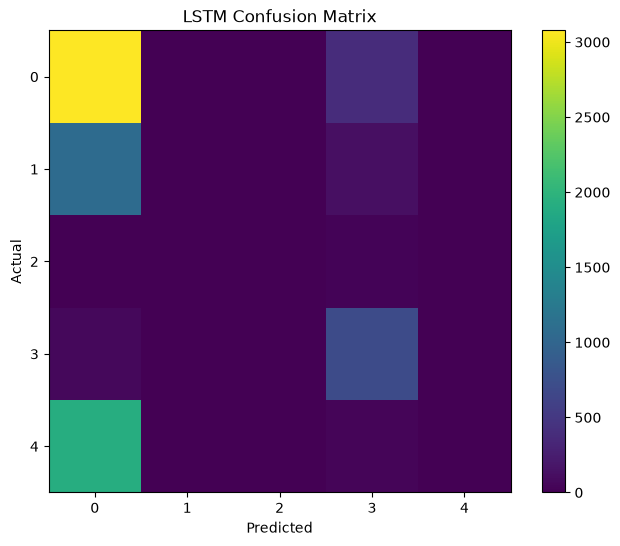

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("LSTM Confusion Matrix")

plt.show()

In [69]:
y_probability = model.predict(X_test)

print(y_probability[0])

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
[4.9120882e-01 1.9483012e-01 7.4704246e-08 3.6844966e-04 2.7716897e-07
 3.1359226e-01]


In [70]:
mental_health_classes = [
    "Anxiety",
    "Depression",
    "Mild Stress",
    "Moderate Stress",
    "Normal",
    "Severe Stress"
]

In [71]:
prediction_index = np.argmax(y_probability[0])

prediction_label = mental_health_classes[prediction_index]

confidence = np.max(y_probability[0])


print("Prediction:", prediction_label)
print("Confidence:", confidence)

Prediction: Anxiety
Confidence: 0.49120882


In [72]:
y_pred = model.predict(X_test)

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [73]:
import numpy as np

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

In [74]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

[[3077    0    0  386    0]
 [1077    0    0  125    0]
 [   0    0    0   35    0]
 [  61    0    0  704    0]
 [1922    0    0   45    0]]


In [75]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

[[3077    0    0  386    0]
 [1077    0    0  125    0]
 [   0    0    0   35    0]
 [  61    0    0  704    0]
 [1922    0    0   45    0]]


In [76]:
import pandas as pd

cm_df = pd.DataFrame(cm)

cm_df

,0,1,2,3,4
0,3077,0,0,386,0
1,1077,0,0,125,0
2,0,0,0,35,0
3,61,0,0,704,0
4,1922,0,0,45,0


In [77]:
cm_df.to_csv(
    r"D:\MindSense\Early_Detection\results\confusion_matrix.csv",
    index=False
)

print("Confusion matrix saved successfully")

Confusion matrix saved successfully


In [78]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred_classes,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

d:\project\MindSense\Early_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\project\MindSense\Early_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\project\MindSense\Early_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

,precision,recall,f1-score,support
0,0.501385,0.888536,0.641042,3463.000000
1,0.000000,0.000000,0.000000,1202.000000
2,0.000000,0.000000,0.000000,35.000000
3,0.543629,0.920261,0.683495,765.000000
5,0.000000,0.000000,0.000000,1967.000000
accuracy,0.508746,0.508746,0.508746,0.508746
macro avg,0.209003,0.361759,0.264907,7432.000000
weighted avg,0.289582,0.508746,0.369053,7432.000000


In [79]:
report_df.to_csv(
    r"D:\MindSense\Early_Detection\results\classification_report.csv"
)

print("Classification report saved successfully")

Classification report saved successfully


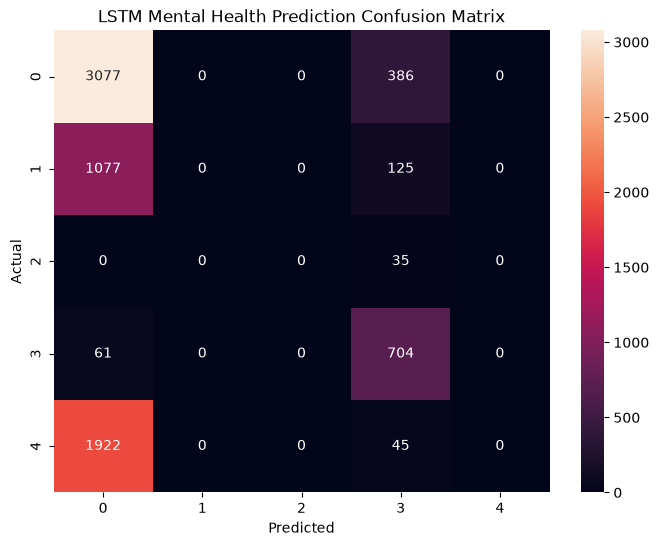

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Mental Health Prediction Confusion Matrix")

plt.show()

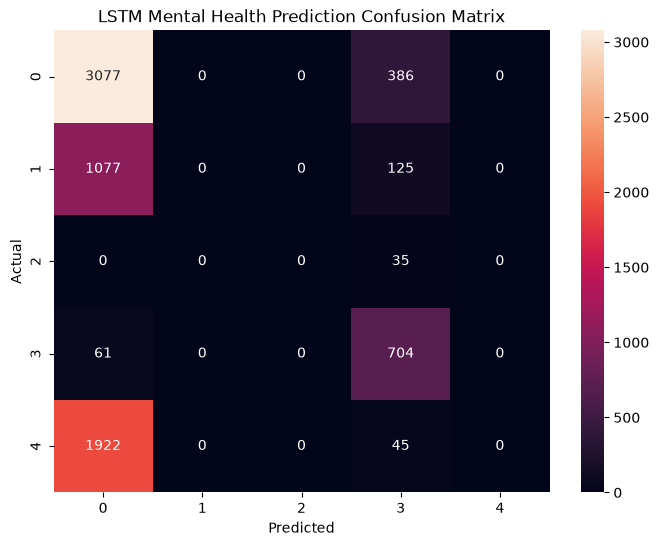

In [81]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Mental Health Prediction Confusion Matrix")

plt.savefig(
    r"D:\MindSense\Early_Detection\results\plots\confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
import pickle

with open(
    r"D:\MindSense\Early_Detection\results\training_history.pkl",
    "rb"
) as file:
    history = pickle.load(file)

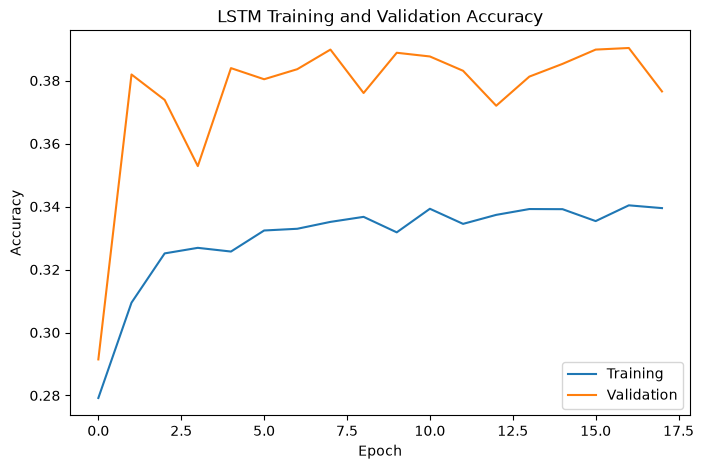

In [83]:
plt.figure(figsize=(8,5))

plt.plot(history["accuracy"])
plt.plot(history["val_accuracy"])

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(
    ["Training", "Validation"]
)

plt.show()

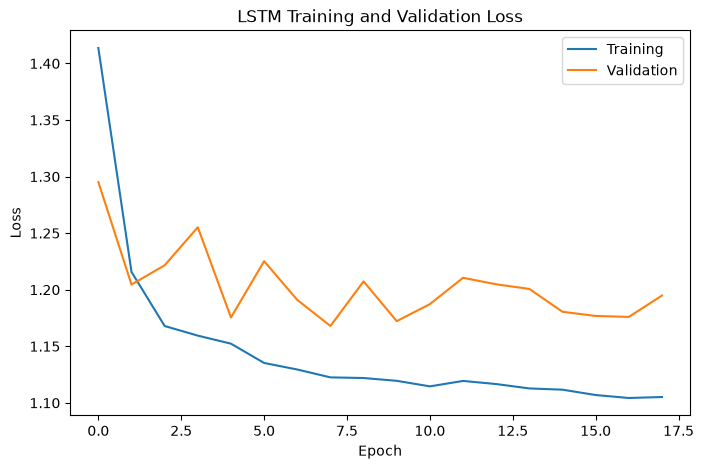

In [84]:
plt.figure(figsize=(8,5))

plt.plot(history["loss"])
plt.plot(history["val_loss"])

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(
    ["Training", "Validation"]
)

plt.show()

In [85]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)